# Reader Feature Notebook

This notebook is designed to exercise the notebook viewer instead of model a full data-science workflow.
It mixes markdown, stdout, tables, JSON payloads, SVG graphics, HTML blocks, and an error cell so the UI can be checked quickly.

In [1]:
repos = [
    {"name": "ada87/GitCodeViewer", "stars": 3200, "language": "TypeScript", "branch": "main", "sync_latency_ms": 84, "docs": ["markdown", "notebook"]},
    {"name": "ada87/notebook-demo", "stars": 980, "language": "Python", "branch": "dev", "sync_latency_ms": 132, "docs": ["notebook"]},
    {"name": "ada87/mermaid-playground", "stars": 640, "language": "Markdown", "branch": "main", "sync_latency_ms": 58, "docs": ["markdown"]},
    {"name": "ada87/mobile-reader", "stars": 410, "language": "Dart", "branch": "release/1.2", "sync_latency_ms": 49, "docs": ["markdown"]},
    {"name": "ada87/frontend-lab", "stars": 820, "language": "Python", "branch": "feature/ui-cache", "sync_latency_ms": 60, "docs": ["markdown"]},
]

notebook_ready = [repo for repo in repos if "notebook" in repo["docs"]]
average_latency = round(sum(repo["sync_latency_ms"] for repo in repos) / len(repos), 1)
print(f"Loaded {len(repos)} repositories from the local cache.")
print(f"{len(notebook_ready)} repos include notebook examples.")
print(f"Average sync latency: {average_latency} ms.")

Loaded 5 repositories from the local cache.
2 repos include notebook examples.
Average sync latency: 76.6 ms.


## Markdown Cell Check

- Headings, lists, and tables should keep their spacing.
- Inline code like `repo["branch"]` should remain readable.
- Fenced blocks should still be highlighted.

| section | purpose |
| --- | --- |
| markdown | headings, lists, tables |
| outputs | stdout, html, json, svg |
| errors | traceback rendering |

> A good preview should stay legible even when the notebook contains mixed content types.

```ts
const supportedDocs = ['markdown', 'mdx', 'ipynb']
```

In [2]:
summary = {}
for repo in repos:
    bucket = summary.setdefault(repo["language"], {"repos": 0, "stars": 0})
    bucket["repos"] += 1
    bucket["stars"] += repo["stars"]

rows = []
for language, item in summary.items():
    rows.append((language, item["repos"], round(item["stars"] / item["repos"])))

sorted(rows, key=lambda row: row[2], reverse=True)

language,repos,avg_stars
TypeScript,1,3200
Python,2,900
Markdown,1,640
Dart,1,410


In [3]:
import statistics

snapshot = {
    "active_branch": "main",
    "dirty_worktree": False,
    "repos_with_notebooks": [repo["name"] for repo in repos if "notebook" in repo["docs"]],
    "average_sync_latency_ms": round(statistics.mean(repo["sync_latency_ms"] for repo in repos), 1),
    "slowest_repo": max(repos, key=lambda repo: repo["sync_latency_ms"])["name"],
}

snapshot

{'active_branch': 'main',
 'dirty_worktree': False,
 'repos_with_notebooks': ['ada87/GitCodeViewer', 'ada87/notebook-demo'],
 'average_sync_latency_ms': 76.6,
 'slowest_repo': 'ada87/notebook-demo'}

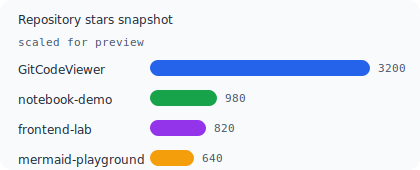

In [4]:
from IPython.display import SVG

SVG('<svg><!-- rich preview omitted for brevity --></svg>')

In [5]:
from IPython.display import HTML

HTML('<div><strong>Feature coverage</strong></div>')

Feature coverage: markdown, stdout, HTML tables, JSON payloads, SVG previews, and error rendering.

In [6]:
raise ValueError('missing branch metadata for repo cache entry: ada87/legacy-sample')

ValueError: missing branch metadata for repo cache entry: ada87/legacy-sample